# 04 — Error Analysis and Grad-CAM Visualization

This notebook investigates the errors made by the trained Xception baseline model on the test dataset and uses Grad-CAM to visualize the image regions that influenced the model predictions.

## Objectives

- Load the best saved Xception baseline model
- Generate predictions for the test dataset
- Identify incorrectly classified test samples
- Analyze the most frequent class confusions
- Save a table containing incorrect predictions
- Visualize selected misclassified MRI images
- Generate Grad-CAM heatmaps for selected predictions
- Compare the true label, predicted label, and prediction confidence

## Why Error Analysis Matters

Overall accuracy alone cannot explain *why* a model fails. Error analysis helps identify systematic mistakes, such as confusing Glioma with Meningioma, low-confidence predictions, mislabeled images, or model attention focused on irrelevant image regions.

Grad-CAM provides a visual explanation by highlighting the regions of an MRI image that contributed most strongly to a specific predicted class.


# 1. Import Needed Libraries

In [ ]:
# ----------------------------------
# Import required libraries
# ----------------------------------

from pathlib import Path
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

# 2. Path & Main Configuration

In [8]:
# ----------------------------------
# Project paths
# ----------------------------------
PROJECT_ROOT = Path("..")

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
DATAFRAMES_DIR = RESULTS_DIR / "dataframes"
ERROR_ANALYSIS_DIR = RESULTS_DIR / "error_analysis"
GRADCAM_DIR = ERROR_ANALYSIS_DIR / "gradcam"

BEST_MODEL_PATH = MODELS_DIR / "xception_baseline.keras"
TEST_DF_PATH = DATAFRAMES_DIR / "test_dataframe.csv"

ERROR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------
# Main settings
# ----------------------------------
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

print("Setup complete.")



Setup complete.


# 3. Load Test DataFrame and Create Test Generator

In [3]:
# ----------------------------------
# Load test dataframe
# ----------------------------------
test_df = pd.read_csv(TEST_DF_PATH)

print(f"Number of test samples: {len(test_df)}")
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df.head())


Number of test samples: 800

Columns:
['filepath', 'label']


,filepath,label
0,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
1,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
2,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
3,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
4,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma


In [6]:
# ----------------------------------
# Create test generator
# ----------------------------------
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

ts_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

labels = list(ts_gen.class_indices.keys())
class_to_index = ts_gen.class_indices
index_to_class = {index: label for label, index in class_to_index.items()}

print("Class indices:", class_to_index)
print("Labels:", labels)



Found 800 validated image filenames belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


# 4. Load the Best Model

In [9]:
# ----------------------------------
# Load trained model
# ----------------------------------
model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Model loaded successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


I0000 00:00:1787597088.092473   34149 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3600 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model loaded successfully.
Model input shape: (None, 299, 299, 3)
Model output shape: (None, 4)


# 5. Generate Predictions

In [10]:
# ----------------------------------
# Generate predictions on the test set
# ----------------------------------
ts_gen.reset()

y_prob = model.predict(ts_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.array(ts_gen.classes)

confidence = np.max(y_prob, axis=1)

print("Prediction probabilities shape:", y_prob.shape)
print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)


I0000 00:00:1787597140.375145   37218 cuda_dnn.cc:529] Loaded cuDNN version 90300


25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step
Prediction probabilities shape: (800, 4)
True labels shape: (800,)
Predicted labels shape: (800,)


# 6. Create and Save Error Analysis DataFrame

In [11]:
# ----------------------------------
# Create a detailed prediction table
# ----------------------------------
predictions_df = test_df.copy()

predictions_df["true_index"] = y_true
predictions_df["predicted_index"] = y_pred

predictions_df["true_label"] = [
    index_to_class[index] for index in y_true
]

predictions_df["predicted_label"] = [
    index_to_class[index] for index in y_pred
]

predictions_df["confidence"] = confidence
predictions_df["is_correct"] = y_true == y_pred

# Store per-class probabilities
for class_index, class_name in index_to_class.items():
    safe_class_name = class_name.lower().replace(" ", "_")
    predictions_df[f"prob_{safe_class_name}"] = y_prob[:, class_index]

print(f"Correct predictions: {predictions_df['is_correct'].sum()}")
print(f"Incorrect predictions: {(~predictions_df['is_correct']).sum()}")

display(predictions_df.head())


Correct predictions: 743
Incorrect predictions: 57


,filepath,label,true_index,predicted_index,true_label,predicted_label,confidence,is_correct,prob_glioma,prob_meningioma,prob_notumor,prob_pituitary
0,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor,2,2,notumor,notumor,0.999682,True,0.000124,0.000131,9.996818e-01,0.000063
1,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,0,0,glioma,glioma,0.999977,True,0.999977,0.000008,4.000189e-07,0.000014
2,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,0,0,glioma,glioma,0.934000,True,0.934000,0.060789,3.964464e-03,0.001246
3,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor,2,2,notumor,notumor,0.999669,True,0.000199,0.000127,9.996694e-01,0.000005
4,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,0,0,glioma,glioma,0.999632,True,0.999632,0.000013,1.178940e-05,0.000343


In [12]:
# ----------------------------------
# Save all predictions and errors
# ----------------------------------
ALL_PREDICTIONS_PATH = ERROR_ANALYSIS_DIR / "all_test_predictions.csv"
MISCLASSIFIED_PATH = ERROR_ANALYSIS_DIR / "misclassified_samples.csv"

predictions_df.to_csv(ALL_PREDICTIONS_PATH, index=False)

misclassified_df = predictions_df[
    ~predictions_df["is_correct"]
].copy()

misclassified_df.to_csv(MISCLASSIFIED_PATH, index=False)

print(f"All predictions saved to:\n{ALL_PREDICTIONS_PATH}")
print(f"Misclassified samples saved to:\n{MISCLASSIFIED_PATH}")


All predictions saved to:
../results/error_analysis/all_test_predictions.csv
Misclassified samples saved to:
../results/error_analysis/misclassified_samples.csv


# 7. Glioma-Specific Error Analysis

In [14]:
# ----------------------------------
# Glioma-specific error analysis
# ----------------------------------
glioma_index = class_to_index["glioma"]
meningioma_index = class_to_index["meningioma"]
notumor_index = class_to_index["notumor"]
pituitary_index = class_to_index["pituitary"]

correct_glioma = np.where(
    (y_true == glioma_index) & (y_pred == glioma_index)
)[0]

glioma_to_meningioma = np.where(
    (y_true == glioma_index) & (y_pred == meningioma_index)
)[0]

glioma_to_notumor = np.where(
    (y_true == glioma_index) & (y_pred == notumor_index)
)[0]

glioma_to_pituitary = np.where(
    (y_true == glioma_index) & (y_pred == pituitary_index)
)[0]

print(f"Correct Glioma: {len(correct_glioma)}")
print(f"Glioma → Meningioma: {len(glioma_to_meningioma)}")
print(f"Glioma → No Tumor: {len(glioma_to_notumor)}")
print(f"Glioma → Pituitary: {len(glioma_to_pituitary)}")


Correct Glioma: 172
Glioma → Meningioma: 13
Glioma → No Tumor: 14
Glioma → Pituitary: 1


In [28]:
# ----------------------------------
# Display detailed Glioma mistakes
# ----------------------------------

# Find probability columns dynamically
probability_columns = [
    column
    for column in predictions_df.columns
    if column.startswith("prob_")
]

display_columns = [
    "filepath",
    "true_label",
    "predicted_label",
    "confidence",
] + probability_columns

glioma_errors_df = predictions_df[
    (predictions_df["true_label"] == "glioma")
    & (~predictions_df["is_correct"])
].sort_values("confidence", ascending=False)

print("Probability columns:")
print(probability_columns)

print(f"\nNumber of misclassified Glioma samples: {len(glioma_errors_df)}")

display(glioma_errors_df[display_columns])


Probability columns:
['prob_glioma', 'prob_meningioma', 'prob_notumor', 'prob_pituitary']

Number of misclassified Glioma samples: 28


,filepath,true_label,predicted_label,confidence,prob_glioma,prob_meningioma,prob_notumor,prob_pituitary
370,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.998989,0.000289,0.000714,0.998989,0.000009
659,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.998335,0.000246,0.001400,0.998335,0.000019
178,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,meningioma,0.991692,0.001705,0.991692,0.003528,0.003075
598,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.988314,0.003658,0.007152,0.988314,0.000877
127,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,meningioma,0.982125,0.008850,0.982125,0.001985,0.007040
299,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.980939,0.004889,0.013927,0.980939,0.000245
755,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.929301,0.021422,0.045317,0.929301,0.003960
281,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,notumor,0.923758,0.014122,0.061747,0.923758,0.000374
203,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,meningioma,0.923564,0.015077,0.923564,0.033358,0.028001
471,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma,meningioma,0.904868,0.016923,0.904868,0.070382,0.007827


# 8. Class Confusion Summary

In [ ]:
# ----------------------------------
# Summarize incorrect class transitions
# ----------------------------------
confusion_summary = (
    misclassified_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

CONFUSION_SUMMARY_PATH = ERROR_ANALYSIS_DIR / "class_confusion_summary.csv"
confusion_summary.to_csv(CONFUSION_SUMMARY_PATH, index=False)

display(confusion_summary)

print(f"Confusion summary saved to:\n{CONFUSION_SUMMARY_PATH}")


,true_label,predicted_label,count
1,glioma,notumor,14
0,glioma,meningioma,13
3,meningioma,glioma,12
6,pituitary,meningioma,8
4,meningioma,notumor,7
5,meningioma,pituitary,2
2,glioma,pituitary,1


Confusion summary saved to:
../results/error_analysis/class_confusion_summary.csv


# 9. Visualize Misclassified MRI Samples

In [30]:
# ----------------------------------
# Display selected misclassified samples
# ----------------------------------
def plot_misclassified_samples(dataframe, n_samples=12):
    """
    Display a selection of incorrectly classified MRI images.
    """
    n_samples = min(n_samples, len(dataframe))

    if n_samples == 0:
        print("No misclassified samples were found.")
        return

    samples = dataframe.sample(
        n=n_samples,
        random_state=42
    ).reset_index(drop=True)

    columns = 4
    rows = math.ceil(n_samples / columns)

    plt.figure(figsize=(18, 4 * rows))

    for i, row in samples.iterrows():
        image = cv2.imread(row["filepath"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, columns, i + 1)
        plt.imshow(image)
        plt.title(
            f"True: {row['true_label']}\n"
            f"Predicted: {row['predicted_label']}\n"
            f"Confidence: {row['confidence']:.2%}",
            fontsize=10
        )
        plt.axis("off")

    plt.tight_layout()

    output_path = ERROR_ANALYSIS_DIR / "misclassified_examples.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to:\n{output_path}")


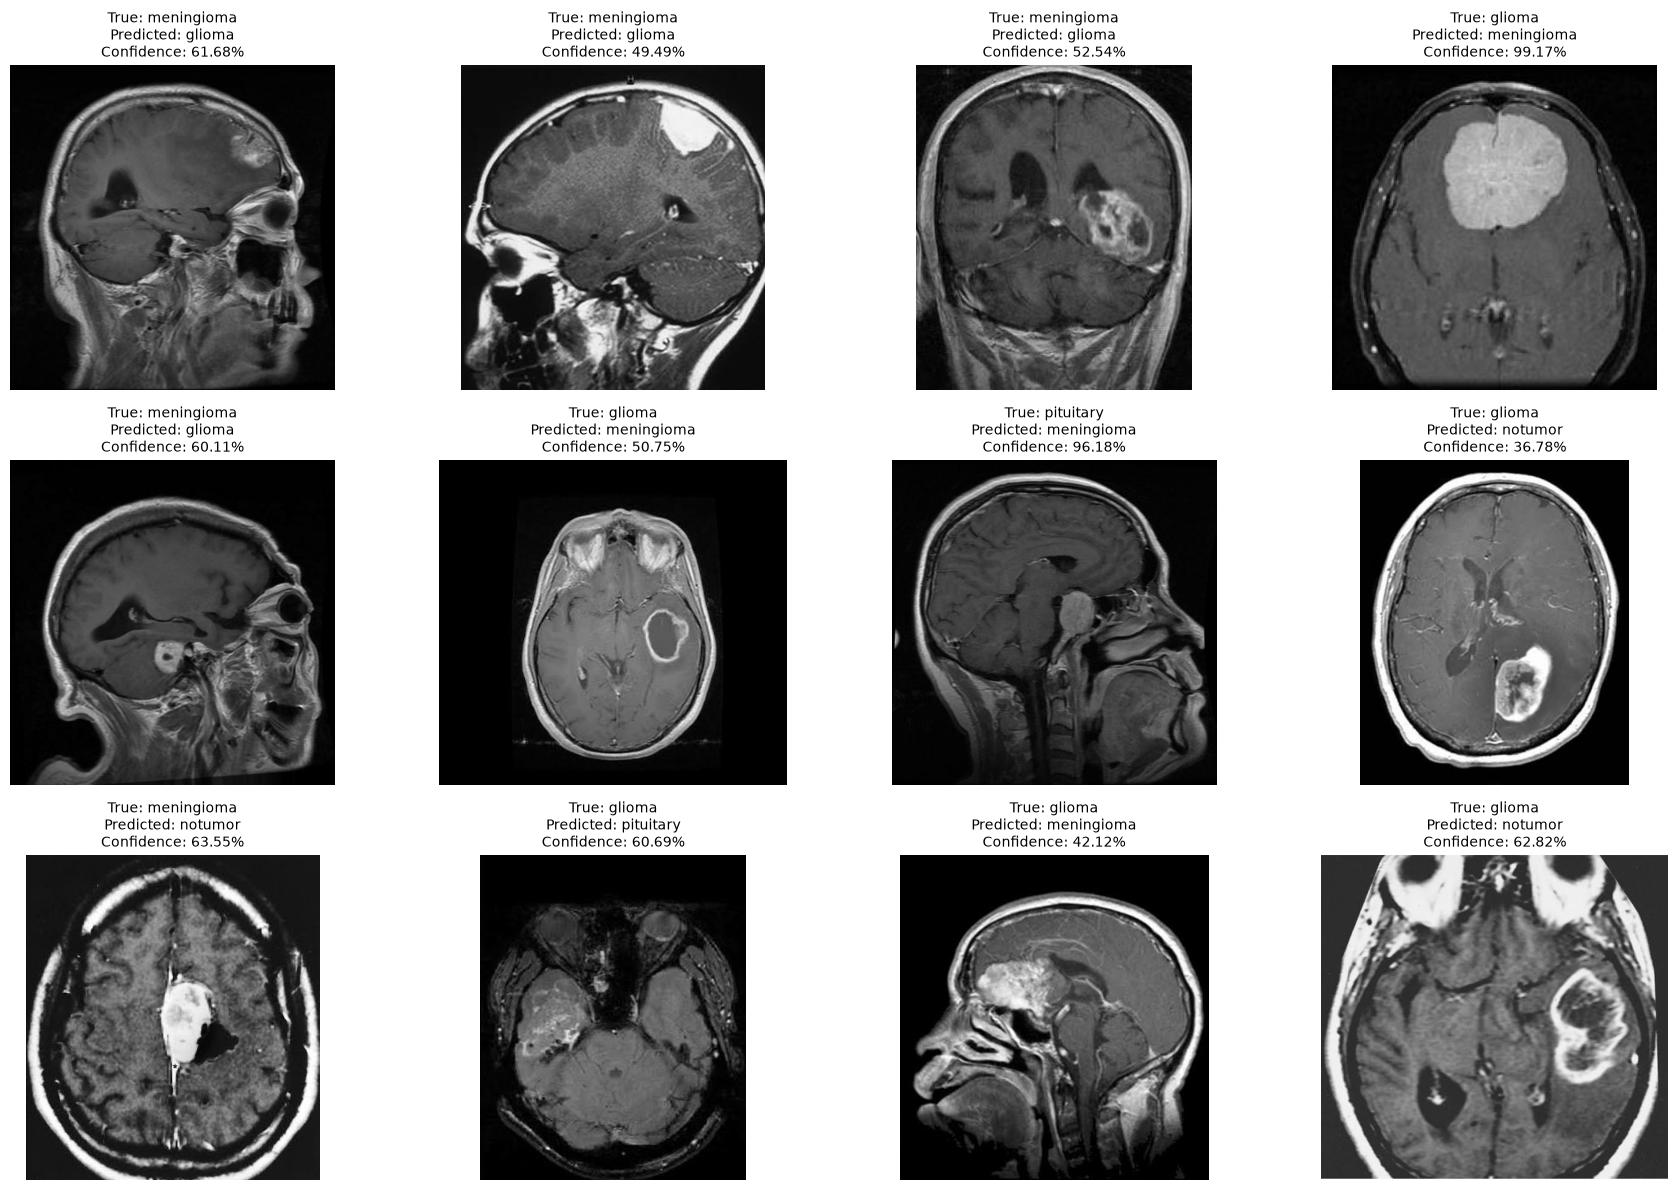

Figure saved to:
../results/error_analysis/misclassified_examples.png


In [31]:
plot_misclassified_samples(
    dataframe=misclassified_df,
    n_samples=12
)


# 10. Find the Last Convolutional Layer


In [32]:
# ----------------------------------
# Inspect model layers related to Xception
# ----------------------------------

xception_model = model.layers[0]

for layer in xception_model.layers[-20:]:
    print(
        layer.name,
        type(layer).__name__,
        layer.output.shape
    )


block12_sepconv3 SeparableConv2D (None, 19, 19, 728)
block12_sepconv3_bn BatchNormalization (None, 19, 19, 728)
add_10 Add (None, 19, 19, 728)
block13_sepconv1_act Activation (None, 19, 19, 728)
block13_sepconv1 SeparableConv2D (None, 19, 19, 728)
block13_sepconv1_bn BatchNormalization (None, 19, 19, 728)
block13_sepconv2_act Activation (None, 19, 19, 728)
block13_sepconv2 SeparableConv2D (None, 19, 19, 1024)
block13_sepconv2_bn BatchNormalization (None, 19, 19, 1024)
conv2d_3 Conv2D (None, 10, 10, 1024)
block13_pool MaxPooling2D (None, 10, 10, 1024)
batch_normalization_3 BatchNormalization (None, 10, 10, 1024)
add_11 Add (None, 10, 10, 1024)
block14_sepconv1 SeparableConv2D (None, 10, 10, 1536)
block14_sepconv1_bn BatchNormalization (None, 10, 10, 1536)
block14_sepconv1_act Activation (None, 10, 10, 1536)
block14_sepconv2 SeparableConv2D (None, 10, 10, 2048)
block14_sepconv2_bn BatchNormalization (None, 10, 10, 2048)
block14_sepconv2_act Activation (None, 10, 10, 2048)
global_max_pool

In [33]:
LAST_CONV_LAYER_NAME = "block14_sepconv2_act"

# 11. Grad-CAM Function

In [72]:
# ----------------------------------
# Grad-CAM implementation
# ----------------------------------
def make_gradcam_heatmap(
    image_array,
    model,
    last_conv_layer_name,
    pred_index=None,
):
    """
    Create a Grad-CAM heatmap for the selected target class.
    """

    # First layer of the complete classifier model: Xception backbone
    xception_model = model.layers[0]

    # Get:
    # - output of the final convolutional layer
    # - output features from Xception backbone
    backbone_grad_model = tf.keras.models.Model(
        inputs=xception_model.input,
        outputs=[
            xception_model.get_layer(last_conv_layer_name).output,
            xception_model.output,
        ],
    )

    # Rebuild classification head:
    # Xception features -> Dropout/Dense/... -> 4 output classes
    classifier_input = tf.keras.Input(
        shape=xception_model.output.shape[1:]
    )

    x = classifier_input

    for layer in model.layers[1:]:
        x = layer(x, training=False)

    classifier_head = tf.keras.models.Model(
        inputs=classifier_input,
        outputs=x,
        name="classifier_head",
    )

    image_array = tf.convert_to_tensor(
        image_array,
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        conv_outputs, backbone_features = backbone_grad_model(
            image_array,
            training=False,
        )

        predictions = classifier_head(
            backbone_features,
            training=False,
        )

        # If no class is manually selected, use model prediction
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        # Score/probability of target class
        class_score = predictions[:, pred_index]

    # Gradient of target class score relative to conv-layer output
    grads = tape.gradient(
        class_score,
        conv_outputs,
    )

    # Mean gradient of each channel
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2),
    )

    # Weighted combination of convolutional activation maps
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Keep positive influence only
    heatmap = tf.maximum(heatmap, 0)

    # Normalize heatmap to [0, 1]
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.cond(
        max_value > 0,
        lambda: heatmap / max_value,
        lambda: heatmap,
    )

    return heatmap.numpy()


# 12. Overlay Heatmap on MRI Image

In [ ]:
# ----------------------------------
# Create Grad-CAM overlay visualizations to interpret model predictions
# by highlighting the image regions that receive the most attention.
# ----------------------------------


def overlay_heatmap(image_rgb, heatmap, alpha=0.4, colormap="jet"):
    """
    Combines an RGB MRI image with a Grad-CAM heatmap.

    Parameters
    ----------
    image_rgb : np.ndarray
        Original RGB MRI image, shape: (height, width, 3).
    heatmap : np.ndarray
        Grad-CAM heatmap.
    alpha : float
        Heatmap transparency. Recommended: 0.3 to 0.5.
    colormap : str
        Matplotlib colormap name, such as 'jet' or 'turbo'.

    Returns
    -------
    np.ndarray
        Final RGB overlay image in uint8 format.
    """

    # Ensure non-negative values and normalize Grad-CAM to [0, 1]
    heatmap = np.maximum(heatmap, 0)
    heatmap_max = np.max(heatmap)

    if heatmap_max > 0:
        heatmap = heatmap / heatmap_max

    # Resize heatmap to match MRI dimensions
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(heatmap * 255)).resize(
            (image_rgb.shape[1], image_rgb.shape[0]),
            resample=Image.Resampling.BILINEAR,
        )
    ).astype("float32") / 255.0

    # New Matplotlib API — compatible with recent versions
    color_map = colormaps.get_cmap(colormap)
    heatmap_colored = color_map(heatmap_resized)[..., :3]

    # Normalize MRI image to [0, 1] if currently in [0, 255]
    image_normalized = image_rgb.astype("float32")

    if image_normalized.max() > 1:
        image_normalized /= 255.0

    # Blend image and Grad-CAM
    overlay = (
        (1 - alpha) * image_normalized
        + alpha * heatmap_colored
    )

    return np.uint8(np.clip(overlay, 0, 1) * 255)


In [ ]:
# ----------------------------------
# Grad-CAM visualization function
# ----------------------------------

def show_gradcam_error_group(
    error_indices,
    group_title,
    filepaths,
    y_true,
    y_pred,
    labels,
    model,
    last_conv_layer_name,
    cols=4,
    alpha=0.4,
    save_path=None,
):
    """
    Display and optionally save Grad-CAM overlays
    for a group of misclassified samples.
    """

    n = len(error_indices)

    if n == 0:
        print(f"No samples found for: {group_title}")
        return

    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
    )

    axes = np.array(axes).reshape(-1)

    fig.suptitle(
        group_title,
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )

    for i, idx in enumerate(error_indices):
        img_path = filepaths[idx]

        # Load and resize the MRI image
        img = Image.open(img_path).convert("RGB").resize((299, 299))
        image_rgb = np.array(img)

        # Prepare image for Xception
        image_array = image_rgb.astype("float32") / 255.0
        image_array = np.expand_dims(image_array, axis=0)

        # Create Grad-CAM based on the incorrect predicted class
        heatmap = make_gradcam_heatmap(
            image_array=image_array,
            model=model,
            last_conv_layer_name=last_conv_layer_name,
            pred_index=int(y_pred[idx]),
        )

        # Create Grad-CAM overlay
        overlay = overlay_heatmap(
            image_rgb,
            heatmap,
            alpha=alpha,
        )

        axes[i].imshow(overlay)

        axes[i].set_title(
            f"True: {labels[y_true[idx]]}\n"
            f"Predicted: {labels[y_pred[idx]]}",
            fontsize=10,
        )

        axes[i].axis("off")

    # Hide empty cells in the Grid
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    # Save the complete Grad-CAM grid if a path is provided
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print(f"Grad-CAM figure saved to: {save_path}")

    plt.show()
    plt.close(fig)


# 13. Generate Grad-CAM for Glioma Misclassifications

In [ ]:

filepaths = ts_gen.filepaths

print(f"Number of filepaths: {len(filepaths)}")
print(f"Number of true labels: {len(y_true)}")
print(f"Number of predicted labels: {len(y_pred)}")

assert len(filepaths) == len(y_true) == len(y_pred), (
    "filepaths, y_true and y_pred must have the same length and order."
)

Number of filepaths: 800
Number of true labels: 800
Number of predicted labels: 800


Grad-CAM figure saved to: ../results/error_analysis/gradcam/glioma_to_meningioma_gradcam.png


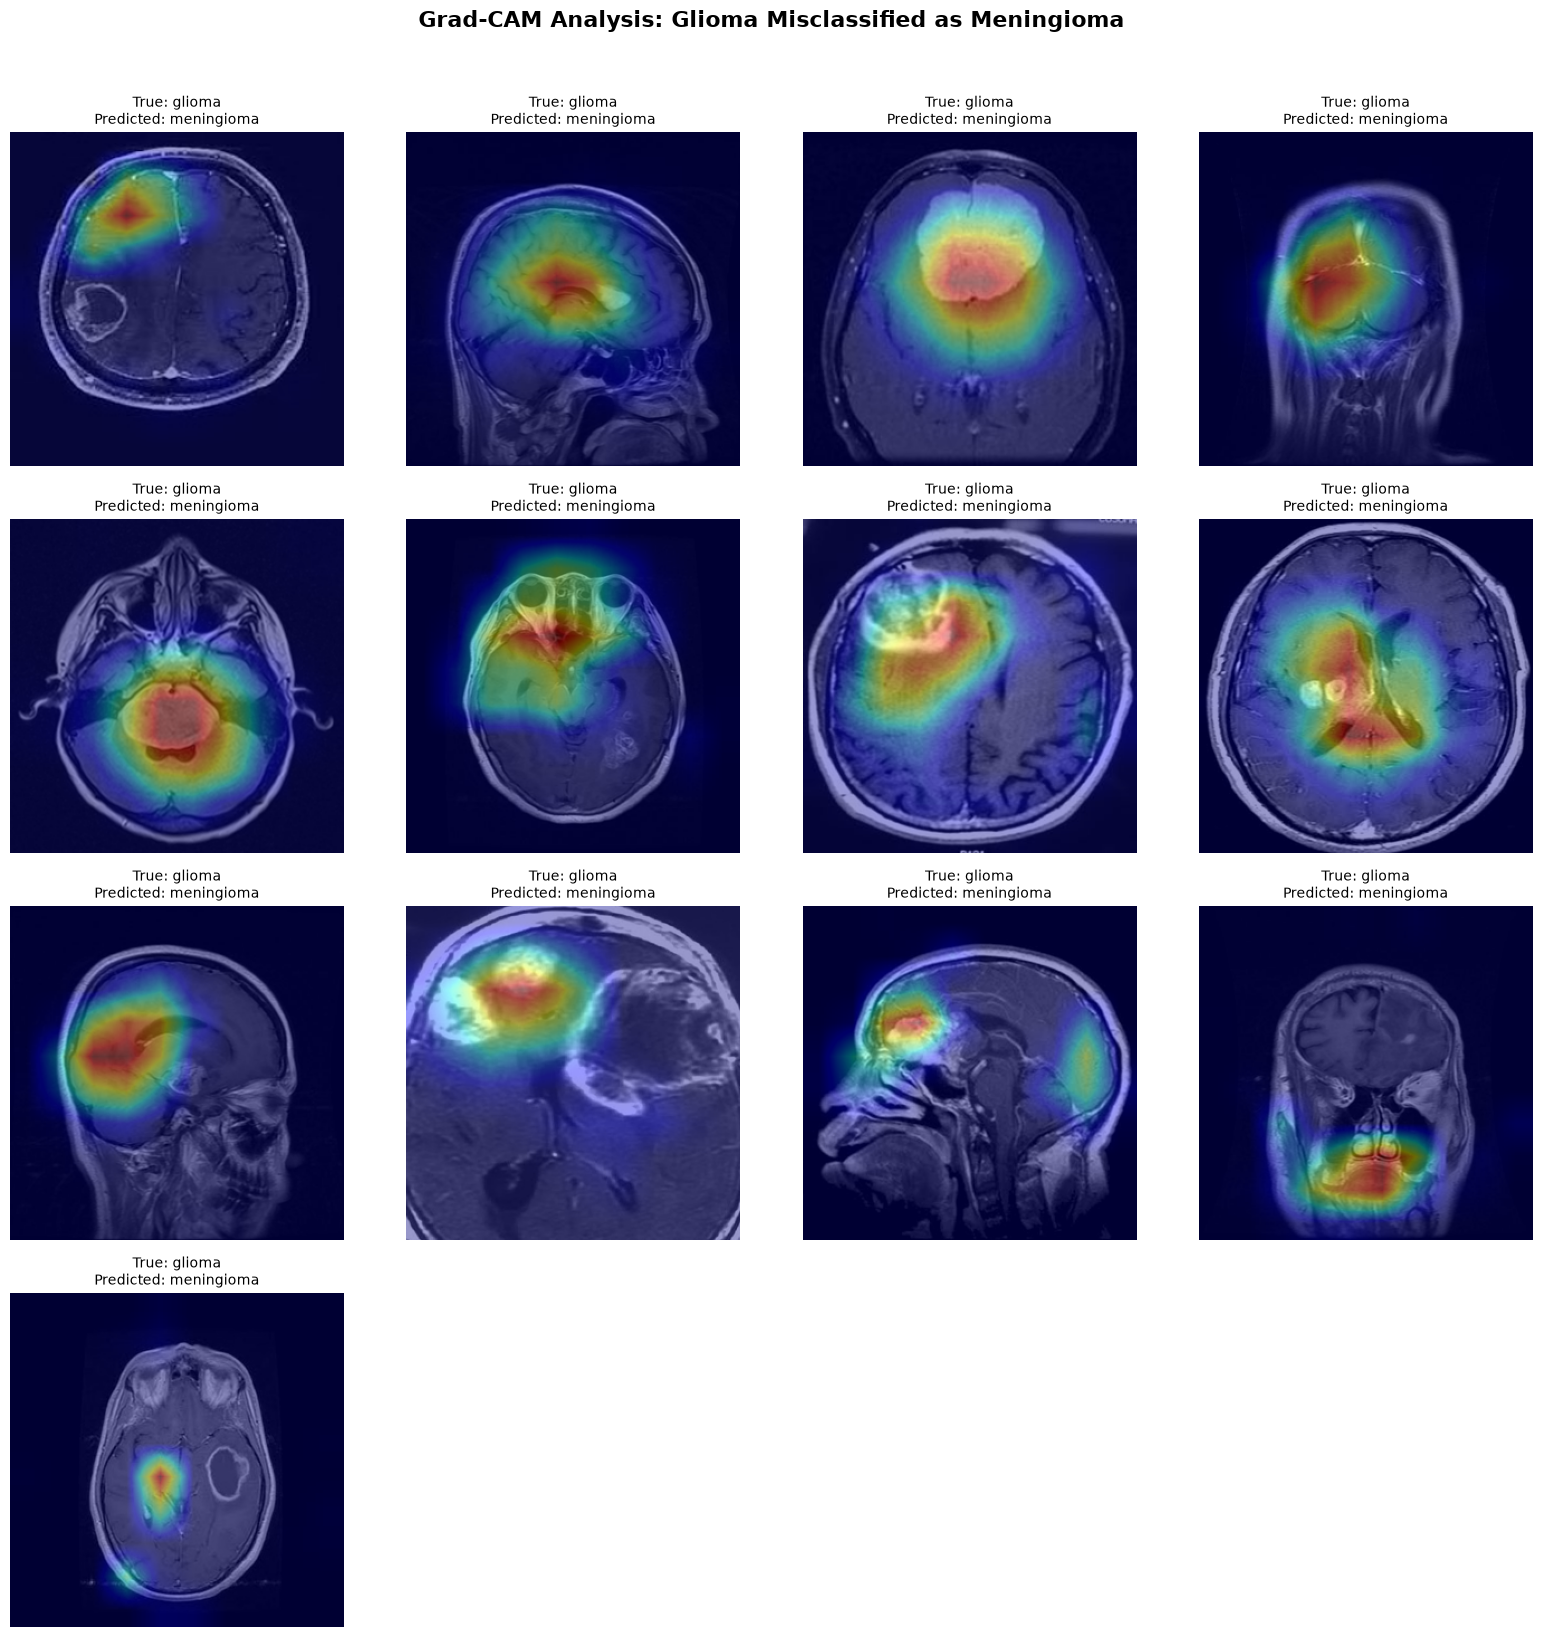

In [105]:
# ----------------------------------
# Display Grad-CAM overlays for all test samples where:
# True class = Glioma
# Predicted class = Meningioma
#
# Each image shows the original MRI combined with the Grad-CAM heatmap.
# The heatmap highlights the regions that influenced the model's
# incorrect "Meningioma" prediction.
# ----------------------------------

show_gradcam_error_group(
    error_indices=glioma_to_meningioma,
    group_title="Grad-CAM Analysis: Glioma Misclassified as Meningioma",
    filepaths=filepaths,
    y_true=y_true,
    y_pred=y_pred,
    labels=labels,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    cols=4,
    alpha=0.4,
    save_path=ERROR_ANALYSIS_DIR / "gradcam/glioma_to_meningioma_gradcam.png",
)

Grad-CAM figure saved to: ../results/error_analysis/gradcam/glioma_to_notumor_gradcam.png


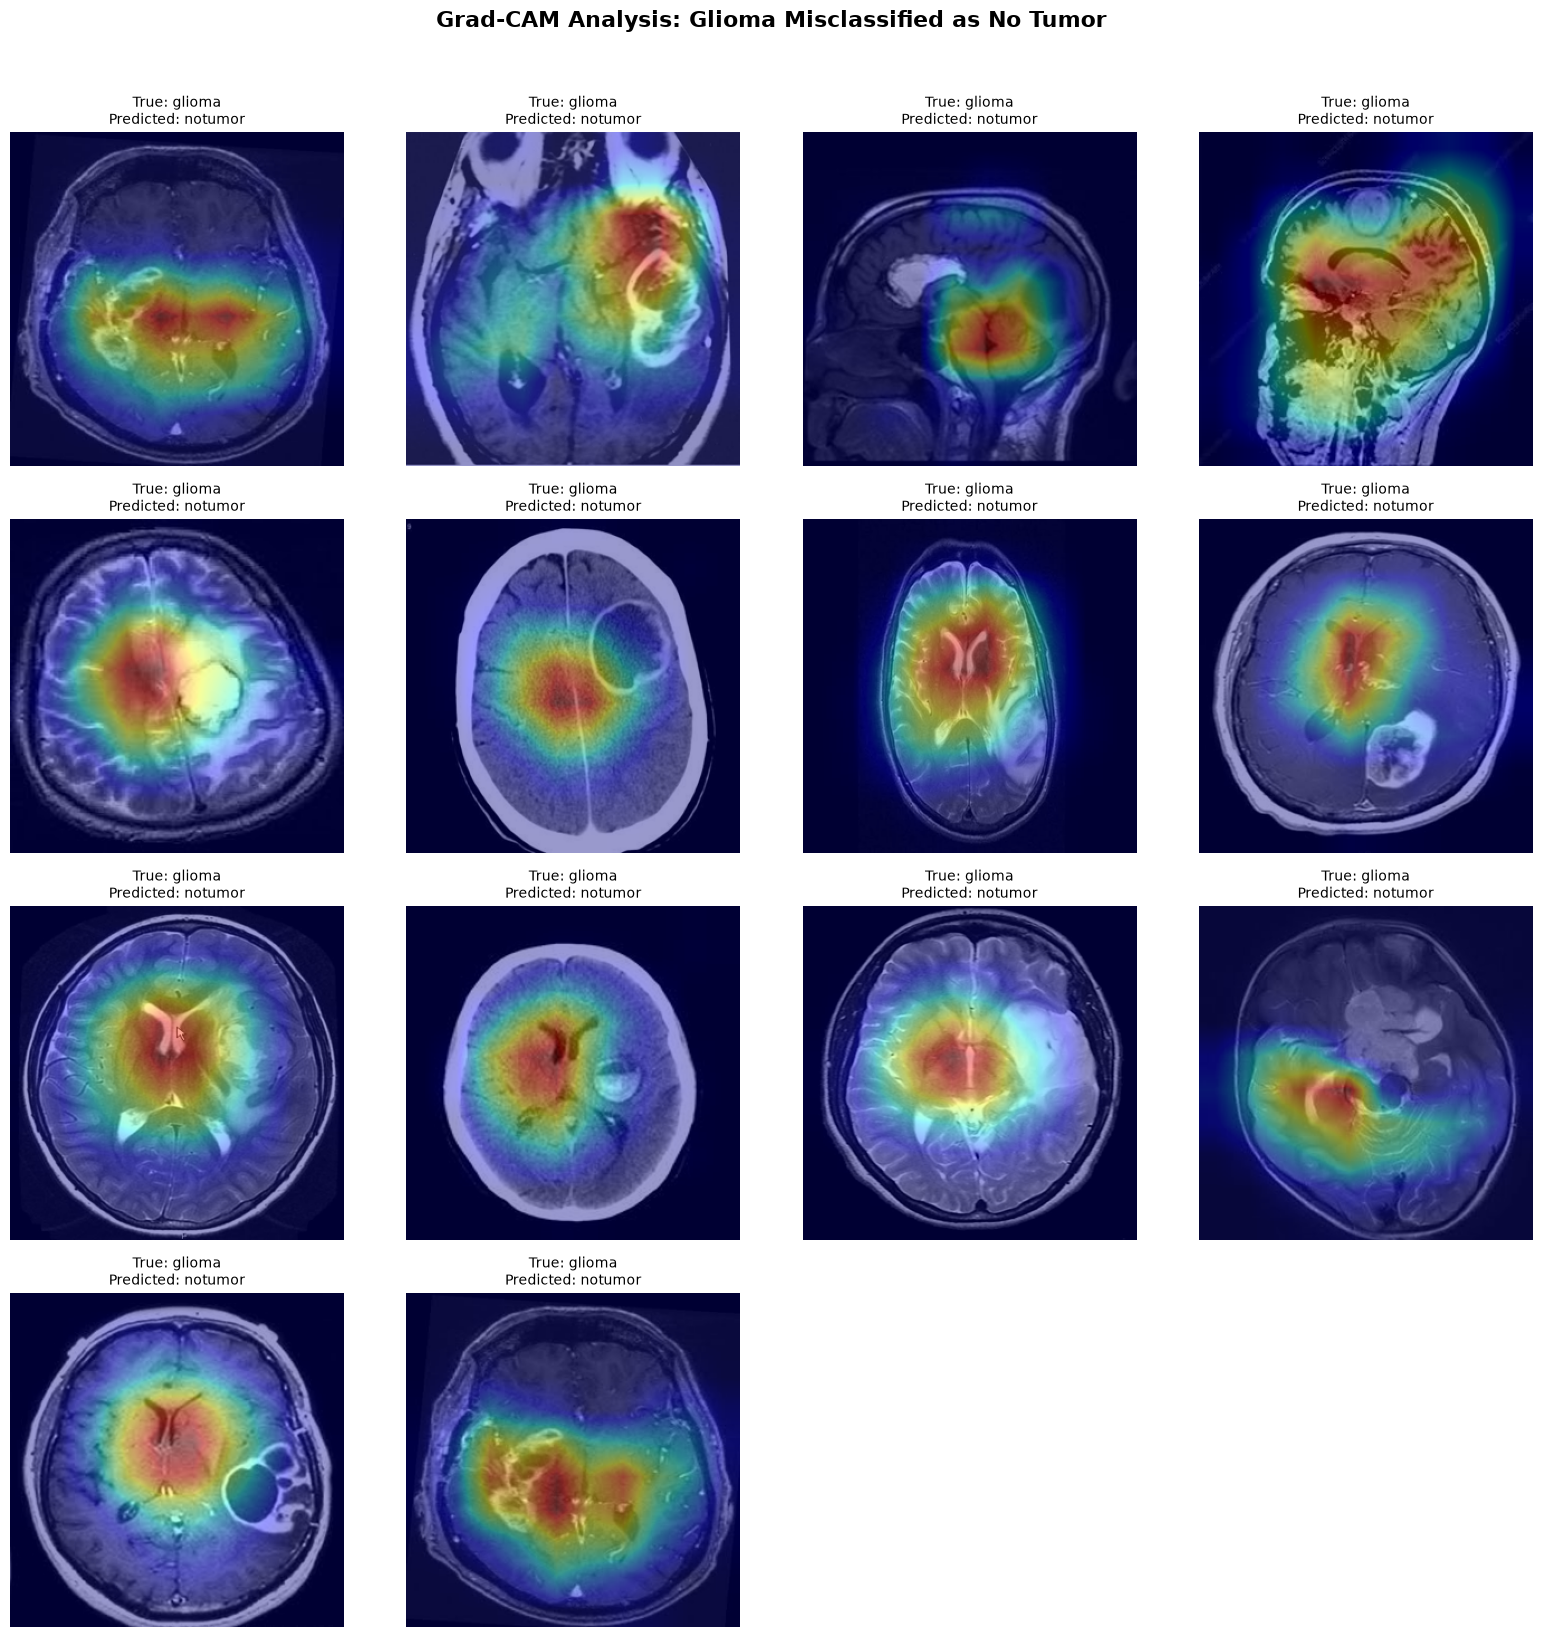

In [106]:
# ----------------------------------
# Display Grad-CAM overlays for all test samples where:
# True class = Glioma
# Predicted class = No Tumor
#
# Each image shows the original MRI combined with the Grad-CAM heatmap.
# The heatmap highlights the regions that influenced the model's
# incorrect "No Tumor" prediction.
# ----------------------------------

show_gradcam_error_group(
    error_indices=glioma_to_notumor,
    group_title="Grad-CAM Analysis: Glioma Misclassified as No Tumor",
    filepaths=filepaths,
    y_true=y_true,
    y_pred=y_pred,
    labels=labels,
    model=model,
    last_conv_layer_name=LAST_CONV_LAYER_NAME,
    cols=4,
    alpha=0.4,
    save_path=ERROR_ANALYSIS_DIR / "gradcam/glioma_to_notumor_gradcam.png",
)

# Conclusion

This notebook investigated the incorrect predictions of the trained Xception
model on the test set and used Grad-CAM to provide visual explanations for
selected misclassified brain MRI images.

Misclassified samples were identified by comparing the true labels with the
predicted labels. The analysis focused on Glioma cases that were incorrectly
predicted as Meningioma or No Tumor, because these error patterns may reflect
visual and learned-feature similarities between the classes.

Grad-CAM visualizations were generated with respect to the incorrectly
predicted class. Therefore, each heatmap highlights the MRI regions that
contributed most strongly to the model's incorrect decision.

The visualizations support qualitative inspection of whether the model focused
on relevant anatomical or lesion-related regions, rather than on irrelevant
parts of the image. However, removing the image background outside the brain
region did not reduce the model's classification errors in this project.
This suggests that the observed errors are not explained solely by background
artifacts or non-brain pixels.

Instead, the remaining misclassifications may be related to factors such as
visual similarity between tumor categories, ambiguous tumor boundaries,
variations in MRI appearance, limited sample diversity, or overlap in the
feature representations learned by the Xception model.

Grad-CAM should be interpreted as an explainability method rather than
definitive clinical evidence. Together with the quantitative evaluation and
feature-space analysis, it provides complementary insight into where the
model focused and why some predictions may remain difficult.
